<a href="https://colab.research.google.com/github/jetisaplane1/AI-for-Business-BUS4-118S/blob/main/DVGAI_Module_Lab_part_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loaded file: /content/adult-all-1.csv
Shape: (48842, 15)
Columns: ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']


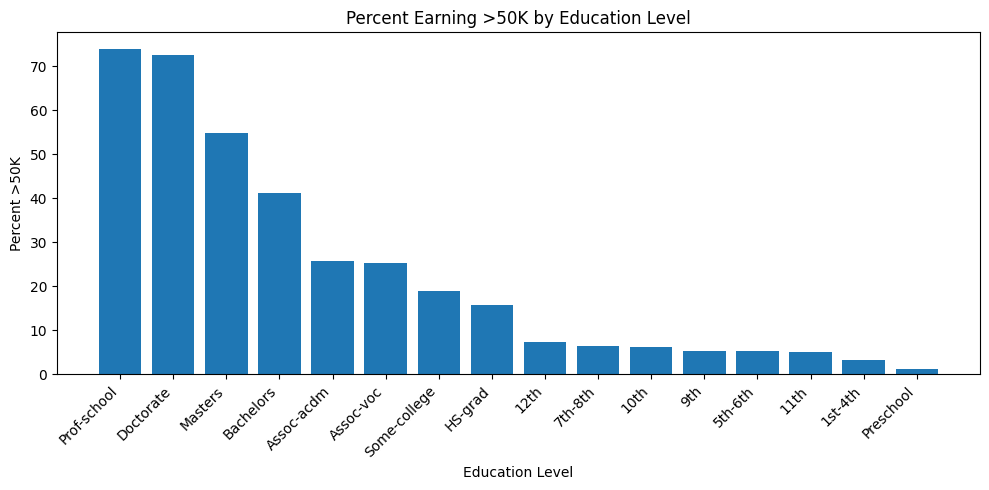


Top 5 education levels by % >50K:
education
Prof-school    73.98
Doctorate      72.56
Masters        54.91
Bachelors      41.28
Assoc-acdm     25.80
Name: >50K, dtype: float64

Bottom 5 education levels by % >50K:
education
9th          5.42
5th-6th      5.30
11th         5.08
1st-4th      3.24
Preschool    1.20
Name: >50K, dtype: float64


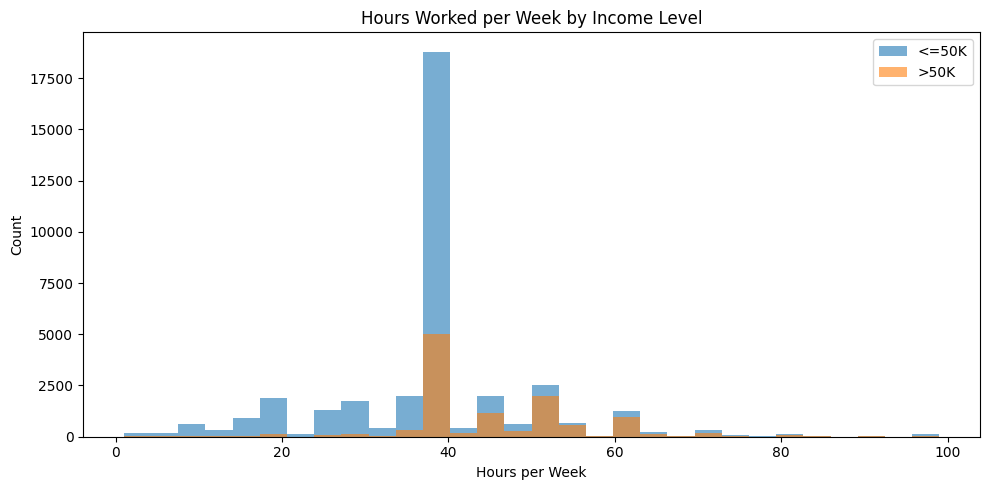

<=50K median hours: 40.0
>50K median hours: 40.0


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# 1) Load the CSV (robust)
# =========================

# In Colab after uploading, this is usually correct:
path_candidates = [Path("/content/adult-all-1.csv"), Path("adult-all-1.csv")]

csv_path = None
for p in path_candidates:
    if p.exists():
        csv_path = p
        break

if csv_path is None:
    raise FileNotFoundError("Could not find adult-all-1.csv. Upload it to Colab (Files panel) first.")

# Expected Adult columns (with income as last column)
col_names = [
    "age","workclass","fnlwgt","education","education-num","marital-status",
    "occupation","relationship","race","sex","capital-gain","capital-loss",
    "hours-per-week","native-country","income"
]

# Try reading with headers first
df_try = pd.read_csv(csv_path)

# If it doesn't look like it has the Adult headers, reload as headerless
# (common: the file has no header and 15 columns)
if not set(["age", "education", "income"]).issubset(set(df_try.columns)) and df_try.shape[1] == 15:
    df = pd.read_csv(csv_path, header=None, names=col_names)
else:
    df = df_try.copy()

# Clean column names + strip whitespace in object columns
df.columns = [c.strip() for c in df.columns]
for c in df.select_dtypes(include="object").columns:
    df[c] = df[c].astype(str).str.strip()

# Convert '?' to NaN
df.replace("?", np.nan, inplace=True)

print("Loaded file:", csv_path)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

# =========================
# 2) Minimal cleaning for Viz 4
# =========================
# Drop rows missing education or income (needed for this chart)
if "education" not in df.columns:
    raise ValueError("Column 'education' not found. Your CSV must include education categories like 'Bachelors', 'HS-grad', etc.")
if "income" not in df.columns:
    # If income column is named differently, detect it by values
    income_col = None
    for c in df.select_dtypes(include="object").columns:
        s = df[c].dropna().astype(str)
        if s.str.contains("<=50K|>50K", regex=True).any():
            income_col = c
            break
    if income_col is None:
        raise ValueError("Could not find the income column (needs values like <=50K or >50K).")
    df.rename(columns={income_col: "income"}, inplace=True)

df_v4 = df.dropna(subset=["education", "income"]).copy()

# Standardize income labels (remove trailing period if present)
df_v4["income"] = df_v4["income"].astype(str).str.replace(".", "", regex=False).str.strip()

# =========================
# 3) Viz 4: % earning >50K by Education
# =========================

high_label = ">50K"
if high_label not in df_v4["income"].unique():
    raise ValueError(f"Expected income label '{high_label}' not found. Found: {df_v4['income'].unique()}")

# Percent >50K for each education category
edu_tab = pd.crosstab(df_v4["education"], df_v4["income"], normalize="index") * 100
edu_pct_high = edu_tab[high_label].sort_values(ascending=False)

# Plot (sorted so higher degrees tend to appear higher)
plt.figure(figsize=(10,5))
plt.bar(edu_pct_high.index.astype(str), edu_pct_high.values)
plt.title("Percent Earning >50K by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Percent >50K")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Optional: print top/bottom to help your narrative sound data-backed
print("\nTop 5 education levels by % >50K:")
print(edu_pct_high.head(5).round(2))

print("\nBottom 5 education levels by % >50K:")
print(edu_pct_high.tail(5).round(2))

# =========================
# 1) Load the CSV (robust)
# =========================
path_candidates = [Path("/content/adult-all-1.csv"), Path("adult-all-1.csv")]
csv_path = next((p for p in path_candidates if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError("Could not find adult-all-1.csv. Upload it to Colab first.")

col_names = [
    "age","workclass","fnlwgt","education","education-num","marital-status",
    "occupation","relationship","race","sex","capital-gain","capital-loss",
    "hours-per-week","native-country","income"
]

df_try = pd.read_csv(csv_path)

# If file has no header but 15 columns, reload with names
if not set(["hours-per-week", "income"]).issubset(set(df_try.columns)) and df_try.shape[1] == 15:
    df = pd.read_csv(csv_path, header=None, names=col_names)
else:
    df = df_try.copy()

# Clean column names + strip whitespace in object columns
df.columns = [c.strip() for c in df.columns]
for c in df.select_dtypes(include="object").columns:
    df[c] = df[c].astype(str).str.strip()

df.replace("?", np.nan, inplace=True)

# Detect/rename income column if needed
if "income" not in df.columns:
    income_col = None
    for c in df.select_dtypes(include="object").columns:
        s = df[c].dropna().astype(str)
        if s.str.contains("<=50K|>50K", regex=True).any():
            income_col = c
            break
    if income_col is None:
        raise ValueError("Could not find the income column (needs values like <=50K or >50K).")
    df.rename(columns={income_col: "income"}, inplace=True)

# Ensure required columns exist
if "hours-per-week" not in df.columns:
    raise ValueError("Column 'hours-per-week' not found. Check df.columns for the correct name.")

# Standardize income labels (remove trailing period like '>50K.')
df["income"] = df["income"].astype(str).str.replace(".", "", regex=False).str.strip()

# =========================
# 2) Clean for Viz 5
# =========================
df_v5 = df.dropna(subset=["income", "hours-per-week"]).copy()
df_v5["hours-per-week"] = pd.to_numeric(df_v5["hours-per-week"], errors="coerce")
df_v5 = df_v5.dropna(subset=["hours-per-week"]).copy()

# Keep values in a reasonable range for readability (Adult dataset is typically 1–99)
df_v5 = df_v5[(df_v5["hours-per-week"] >= 1) & (df_v5["hours-per-week"] <= 99)]

# Split by income group
low = df_v5[df_v5["income"] == "<=50K"]["hours-per-week"]
high = df_v5[df_v5["income"] == ">50K"]["hours-per-week"]

if len(low) == 0 or len(high) == 0:
    raise ValueError(f"Missing one of the income groups. Found income labels: {df_v5['income'].unique()}")

# =========================
# 3) Viz 5: Hours Worked per Week by Income (Histogram Overlay)
# =========================
plt.figure(figsize=(10,5))
plt.hist(low, bins=30, alpha=0.6, label="<=50K")
plt.hist(high, bins=30, alpha=0.6, label=">50K")
plt.title("Hours Worked per Week by Income Level")
plt.xlabel("Hours per Week")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

# Optional: print medians to make your narrative more data-backed
print("<=50K median hours:", round(low.median(), 2))
print(">50K median hours:", round(high.median(), 2))